In [1]:
import os
import numpy as np
import tifffile
from scipy import ndimage as ndi
import napari
import matplotlib.pyplot as plt
import pandas as pd

In [219]:
labels_path = "/Users/elyssephillips/Desktop/20260129_fgf_cdx2_ppmlc_gata3/seg/cleaned/c_001_segmentation.tif"
raw_path = "/Users/elyssephillips/Desktop/20260129_fgf_cdx2_ppmlc_gata3/tifs/c_001.tif"
out_dir = "/Users/elyssephillips/Desktop/20260129_fgf_cdx2_ppmlc_gata3/tifs/analyzed"
os.makedirs(out_dir, exist_ok=True)


identifier = os.path.splitext(os.path.basename(raw_path))[0]

print("Identifier:", identifier)

Identifier: c_001


In [220]:
# set voxels
voxel_size_um = (0.8, 0.123, 0.123)  # (z,y,x)
scale = voxel_size_um                # napari uses (z,y,x) scaling for 3D stacks

In [221]:
#define channels
DAPI_CH = 0
CH1    = 1 #gata3
CH2    = 2 #myosin
CH3    = 3 #cdx2

In [222]:
# set erosion parameters

erode_xy_um = 1.0   # 0.5 µm in XY
erode_z_um  = 3.2   # 0.8 µm in Z (one slice)

erode_xy_px = int(round(erode_xy_um / voxel_size_um[1]))  # y/x spacing
erode_z_px  = int(round(erode_z_um  / voxel_size_um[0]))  # z spacing

print("Erosion in pixels/slices:", {"erode_xy_px": erode_xy_px, "erode_z_px": erode_z_px})

Erosion in pixels/slices: {'erode_xy_px': 8, 'erode_z_px': 4}


In [223]:
#load image and label stacks
img = tifffile.imread(raw_path)
labels = tifffile.imread(labels_path)

print("img shape:", img.shape, "dtype:", img.dtype)
print("labels shape:", labels.shape, "dtype:", labels.dtype)

assert labels.ndim == 3, "labels must be 3D (Z,Y,X) integer IDs."

img shape: (138, 4, 756, 999) dtype: uint16
labels shape: (138, 756, 999) dtype: uint16


(np.float64(-0.5), np.float64(998.5), np.float64(755.5), np.float64(-0.5))

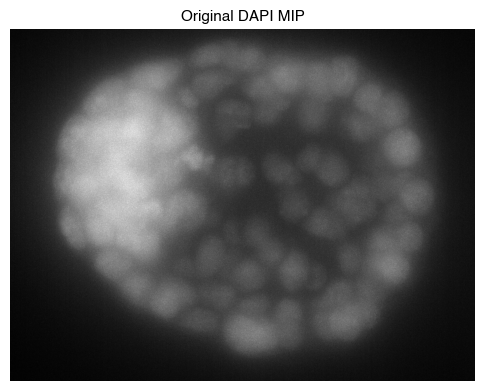

In [ ]:
def get_channel_zyx(img, c):
    if img.ndim != 4:
        raise ValueError(f"Expected 4D (channels). Got {img.shape}")

    # (Z,C,Y,X)
    if img.shape[1] == 4:
        return img[:, c, :, :]

dapi_zyx = get_channel_zyx(img, DAPI_CH)

# Make MIP
dapi_mip = dapi_zyx.max(axis=0)

plt.figure(figsize=(6,6))
plt.imshow(dapi_mip, cmap="gray")
plt.title("Original DAPI MIP")
plt.axis("off")


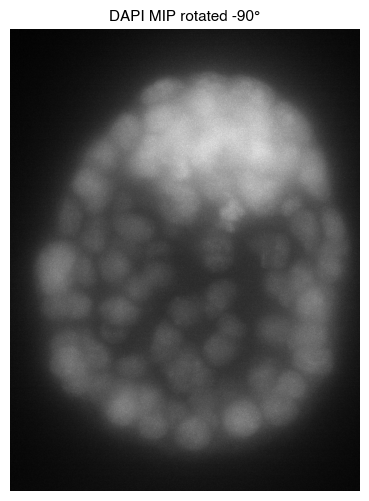

In [225]:
angle = -90  # change this number and re-run

rot = ndi.rotate(dapi_mip, angle, reshape=True, order=1)

plt.figure(figsize=(6,6))
plt.imshow(rot, cmap="gray")
plt.title(f"DAPI MIP rotated {angle}°")
plt.axis("off")
plt.show()

In [226]:
# rotate so ICM is up
def rotate_zyx(vol, angle, order, cval=0):
    """Rotate a 3D (Z,Y,X) volume in the XY plane (axes=(1,2)), keeping all content."""
    return ndi.rotate(
        vol,
        angle,
        axes=(1, 2),
        reshape=True,        # ✅ keep all content (no cropping)
        order=order,         # 1 for images, 0 for labels
        mode="constant",
        cval=cval
    )

def rotate_img(img, angle):
    """
    Rotate full 4D image in XY plane.
    Supports (Z,C,Y,X) with C=4.
    Returns rotated image with shape (Z,C,Y2,X2).
    """
    if img.ndim == 4 and img.shape[1] == 4:  # (Z,C,Y,X)
        rotated_channels = []
        for c in range(4):
            vol = img[:, c, :, :].astype(np.float32)
            cval = float(np.min(vol))  # reasonable background fill
            vol_rot = rotate_zyx(vol, angle, order=1, cval=cval)
            rotated_channels.append(vol_rot)
        out = np.stack(rotated_channels, axis=1)  # (Z,C,Y2,X2)

        # cast back to original dtype safely
        if np.issubdtype(img.dtype, np.integer):
            info = np.iinfo(img.dtype)
            out = np.clip(out, info.min, info.max).astype(img.dtype)
        else:
            out = out.astype(img.dtype)

        return out

    raise ValueError(f"Unexpected 4ch shape: {img.shape} (expected (Z,4,Y,X))")


# --- Run rotation ---
img_rotated = rotate_img(img, angle)

# Labels must use nearest-neighbor (order=0) to preserve integer IDs
labels_rotated = rotate_zyx(labels, angle, order=0, cval=0).astype(labels.dtype)

# Sanity check: shapes should match in (Z,Y,X)
dapi_rotated = img_rotated[:, DAPI_CH, :, :]   # (Z,Y,X)
assert dapi_rotated.shape == labels_rotated.shape, (
    f"Rotated image and labels must match. Got {dapi_rotated.shape} vs {labels_rotated.shape}"
)

print("Rotated img:", img_rotated.shape, "Rotated labels:", labels_rotated.shape)

Rotated img: (138, 4, 999, 756) Rotated labels: (138, 999, 756)


In [227]:
#split channels
dapi = get_channel_zyx(img_rotated, DAPI_CH)
ch1  = get_channel_zyx(img_rotated, CH1)
ch2  = get_channel_zyx(img_rotated, CH2)
ch3  = get_channel_zyx(img_rotated, CH3)

In [228]:

# erode labels per nucleus ID

def make_anisotropic_selem(erode_xy_px: int, erode_z_px: int):
    zz = max(0, int(erode_z_px))
    rr = max(0, int(erode_xy_px))
    if zz == 0 and rr == 0:
        return np.ones((1, 1, 1), dtype=bool)

    z = np.arange(-zz, zz + 1)
    y = np.arange(-rr, rr + 1)
    x = np.arange(-rr, rr + 1)
    Z, Y, X = np.meshgrid(z, y, x, indexing="ij")

    denom_z = zz if zz > 0 else 1
    denom_r = rr if rr > 0 else 1
    return (Z / denom_z) ** 2 + (Y / denom_r) ** 2 + (X / denom_r) ** 2 <= 1.0

def erode_labels_per_object(labels_zyx: np.ndarray, erode_xy_px: int, erode_z_px: int) -> np.ndarray:
    out = np.zeros_like(labels_zyx, dtype=labels_zyx.dtype)
    selem = make_anisotropic_selem(erode_xy_px, erode_z_px)

    ids = np.unique(labels_zyx)
    ids = ids[ids != 0]

    for lab in ids:
        mask = (labels_zyx == lab)
        eroded = ndi.binary_erosion(mask, structure=selem)
        out[eroded] = lab

    return out

labels_eroded = erode_labels_per_object(labels_rotated, erode_xy_px=erode_xy_px, erode_z_px=erode_z_px)
removed_mask = (labels_rotated != 0) & (labels_eroded == 0)

print("original labeled voxels:", int((labels != 0).sum()))
print("eroded labeled voxels:", int((labels_eroded != 0).sum()))

original labeled voxels: 6052021
eroded labeled voxels: 2403741


In [92]:
# check it out
viewer = napari.Viewer(ndisplay=3)

viewer.add_image(dapi, name="DAPI", scale=scale, colormap="gray", rendering="mip")
viewer.add_image(ch1,  name="CH1",  scale=scale, colormap="gray", rendering="mip")
viewer.add_image(ch2,  name="CH2",  scale=scale, colormap="gray", rendering="mip")
viewer.add_image(ch3,  name="CH3",  scale=scale, colormap="gray", rendering="mip")

viewer.add_labels(labels_rotated, name="labels_original", scale=scale, opacity=0.30)
viewer.add_labels(labels_eroded, name="labels_eroded",   scale=scale, opacity=0.55)

viewer.add_image(removed_mask.astype(np.uint8), name="erosion_removed_mask", scale=scale, opacity=0.35)

napari.run()

In [229]:
# quantify channel intensities per nucleus
def per_label_intensity(labels_zyx, img_zyx, prefix):
    ids = np.unique(labels_zyx)
    ids = ids[ids != 0]
    rows = []
    for lab in ids:
        m = (labels_zyx == lab)
        vals = img_zyx[m]
        rows.append({
            "label_id": int(lab),
            f"{prefix}_nvox": int(m.sum()),
            f"{prefix}_mean": float(vals.mean()),
            f"{prefix}_median": float(np.median(vals)),
            f"{prefix}_p90": float(np.percentile(vals, 90)),
        })
    return pd.DataFrame(rows)

df_int = per_label_intensity(labels_eroded, dapi, "dapi")
df_int = df_int.merge(per_label_intensity(labels_eroded, ch1, "ch1").drop(columns=["ch1_nvox"]), on="label_id")
df_int = df_int.merge(per_label_intensity(labels_eroded, ch2, "ch2").drop(columns=["ch2_nvox"]), on="label_id")
df_int = df_int.merge(per_label_intensity(labels_eroded, ch3, "ch3").drop(columns=["ch3_nvox"]), on="label_id")

In [230]:
# Optional: normalize by DAPI median (avoid div-by-zero)
eps = 1e-6
for c in ["ch1", "ch2", "ch3"]:
    df_int[f"{c}_over_dapi"] = df_int[f"{c}_median"] / (df_int["dapi_median"] + eps)
df_int.head()

,label_id,dapi_nvox,dapi_mean,dapi_median,dapi_p90,ch1_mean,ch1_median,ch1_p90,ch2_mean,ch2_median,ch2_p90,ch3_mean,ch3_median,ch3_p90,ch1_over_dapi,ch2_over_dapi,ch3_over_dapi
0,1,31395,341.993948,341.0,390.0,782.053798,792.0,931.0,493.696703,495.0,546.0,821.867527,831.0,959.0,2.322581,1.451613,2.436950
1,2,46025,502.257360,505.0,569.0,548.639674,556.0,637.0,739.095426,761.0,867.0,786.242064,786.0,915.0,1.100990,1.506931,1.556436
2,3,23202,394.479700,394.0,437.0,1323.586630,1340.0,1490.0,583.040384,582.0,637.0,794.832299,797.0,896.0,3.401015,1.477157,2.022843
3,4,42426,346.383256,346.0,386.0,1119.494838,1120.0,1317.0,534.864871,535.0,598.0,681.479942,680.0,793.0,3.236994,1.546243,1.965318
4,5,33569,412.406417,412.0,456.0,1229.436772,1235.0,1353.0,583.982901,584.0,639.0,699.126575,701.0,771.0,2.997573,1.417476,1.701456


In [231]:
#save dataframe
df_int.insert(0, "file_id", identifier)


csv_name = f"{identifier}_nuclear_intensities.csv"
csv_path = os.path.join(out_dir, csv_name)

df_int.to_csv(csv_path, index=False)

print("Saved:", csv_path)

Saved: /Users/elyssephillips/Desktop/20260129_fgf_cdx2_ppmlc_gata3/tifs/analyzed/c_001_nuclear_intensities.csv


In [232]:
#visualize normalized nuclear intensity as a 3d heatmap
def make_label_value_volume(labels_rotated, df, value_col, label_col="label_id", fill=np.nan):
    """
    labels: (Z,Y,X) int label image
    df: dataframe with per-label values
    value_col: column in df to map onto labels
    Returns float32 volume where each label's voxels = that label's value.
    Background = fill (default NaN so it displays transparent if you mask it).
    """
    labels = labels_rotated.astype(np.int64, copy=False)
    max_id = int(labels.max())

    lut = np.full(max_id + 1, fill, dtype=np.float32)  # lookup table
    # Fill LUT with values
    for lab, val in zip(df[label_col].astype(int).values, df[value_col].astype(float).values):
        if 0 <= lab <= max_id:
            lut[lab] = val

    vol = lut[labels]  # vectorized mapping, fast
    return vol.astype(np.float32)

# Build heatmap volumes for each standardized channel
heat_ch1 = make_label_value_volume(labels_rotated, df_int, "ch1_over_dapi")
heat_ch2 = make_label_value_volume(labels_rotated, df_int, "ch2_over_dapi")
heat_ch3 = make_label_value_volume(labels_rotated, df_int, "ch3_over_dapi")

def robust_limits(vol, lo=1, hi=99):
    v = vol[np.isfinite(vol)]
    if v.size == 0:
        return (0, 1)
    return (float(np.percentile(v, lo)),
            float(np.percentile(v, hi)))

# Compute limits right here (so they always exist)
clim1 = robust_limits(heat_ch1)
clim2 = robust_limits(heat_ch2)
clim3 = robust_limits(heat_ch3)

viewer = napari.Viewer(ndisplay=3)

viewer.add_labels(labels_rotated, name="labels", scale=scale, opacity=0.3)

viewer.add_image(
    heat_ch1,
    name="CH1 standardized",
    scale=scale,
    contrast_limits=clim1,
    opacity=0.8,
    rendering="mip",
)

viewer.add_image(
    heat_ch2,
    name="CH2 standardized",
    scale=scale,
    contrast_limits=clim2,
    opacity=0.8,
    rendering="mip",
)

viewer.add_image(
    heat_ch3,
    name="CH3 standardized",
    scale=scale,
    contrast_limits=clim3,
    opacity=0.8,
    rendering="mip",
)

for layer in viewer.layers:
    layer.scale = scale

# verify
for layer in viewer.layers:
    print(layer.name, "scale:", layer.scale, "world extent:", layer.extent.world)

napari.run()

labels scale: [0.8   0.123 0.123] world extent: [[  0.      0.      0.   ]
 [109.6   122.754  92.865]]
CH1 standardized scale: [0.8   0.123 0.123] world extent: [[  0.      0.      0.   ]
 [109.6   122.754  92.865]]
CH2 standardized scale: [0.8   0.123 0.123] world extent: [[  0.      0.      0.   ]
 [109.6   122.754  92.865]]
CH3 standardized scale: [0.8   0.123 0.123] world extent: [[  0.      0.      0.   ]
 [109.6   122.754  92.865]]


In [233]:
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.cm import ScalarMappable
import matplotlib.patheffects as pe

# ---------- global style (applies to all exported figures) ----------
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
    "font.size": 10,
    "axes.titlesize": 11,
})


def safe_nanmax_mip(vol3d):
    mip = np.nanmax(np.where(np.isnan(vol3d), -np.inf, vol3d), axis=0)
    mip[mip == -np.inf] = np.nan
    return mip

def to_unit_interval(x, vmin, vmax):
    x = (x - vmin) / (vmax - vmin)
    x = np.clip(x, 0, 1)
    x[~np.isfinite(x)] = 0
    return x

def save_fig_tiff(fig, out_path, dpi=300):
    os.makedirs(os.path.dirname(out_path), exist_ok=True)
    # Tight but with padding so titles/labels never clip
    fig.savefig(out_path, format="tiff", dpi=dpi, bbox_inches="tight", pad_inches=0.18)
    plt.close(fig)
    print("Saved:", out_path)

def add_scalebar_pretty(ax, h, w, voxel_size_xy, scalebar_um, color="white"):
    """Scale bar in bottom-right with outlined text for readability."""
    scalebar_px = int(round(scalebar_um / voxel_size_xy))
    pad = 24
    y = h - pad
    x2 = w - pad
    x1 = max(pad, x2 - scalebar_px)

    # bar
    ax.plot([x1, x2], [y, y],
            linewidth=6, solid_capstyle="butt", color=color,
            path_effects=[pe.Stroke(linewidth=8, foreground="black"), pe.Normal()])

    # text
    txt = ax.text((x1 + x2) / 2, y - 14, f"{scalebar_um} µm",
                  color=color, ha="center", va="bottom", fontsize=10)
    txt.set_path_effects([pe.Stroke(linewidth=3, foreground="black"), pe.Normal()])

# ----------  turbo saver ----------
def save_turbo_quant_mip_with_legend_tiff(
    heat_3d, out_path, title,
    vmin=0.0, vmax=3.5,
    voxel_size_xy=0.122666664, scalebar_um=20,
    dpi=300,
    ticks=None
):
    mip = safe_nanmax_mip(heat_3d)
    norm01 = to_unit_interval(mip, vmin, vmax)

    cmap = plt.get_cmap("turbo")
    rgb = cmap(norm01)[..., :3]

    h, w = norm01.shape

    fig = plt.figure(figsize=((w/240)*1.35, (h/240)), dpi=dpi)
    gs = fig.add_gridspec(1, 2, width_ratios=[1.0, 0.06], wspace=0.15)

    ax = fig.add_subplot(gs[0, 0])
    cax = fig.add_subplot(gs[0, 1])

    ax.imshow(rgb, interpolation="nearest")
    ax.set_axis_off()
    ax.set_title(title, pad=6)

    add_scalebar_pretty(ax, h, w, voxel_size_xy, scalebar_um)

    sm = ScalarMappable(norm=Normalize(vmin=vmin, vmax=vmax), cmap="turbo")
    cb = fig.colorbar(sm, cax=cax)

    if ticks is None:
        ticks = [vmin, (vmin+vmax)/2, vmax]

    cb.set_ticks(ticks)
    cb.ax.tick_params(labelsize=8, length=3)

    # Light spines
    for spine in cb.ax.spines.values():
        spine.set_linewidth(0.5)
        spine.set_alpha(0.6)

    save_fig_tiff(fig, out_path, dpi=dpi)

def save_magenta_cyan_composite_mip_with_legends_tiff(
    heat_ch1_3d, heat_ch3_3d, out_path, title,
    vmin=0.0, vmax_ch1=3.5, vmax_ch3=3.5,
    voxel_size_xy=0.122666664, scalebar_um=20,
    dpi=300
):
    mip1 = safe_nanmax_mip(heat_ch1_3d)
    mip3 = safe_nanmax_mip(heat_ch3_3d)

    n1 = to_unit_interval(mip1, vmin, vmax_ch1)
    n3 = to_unit_interval(mip3, vmin, vmax_ch3)

    # Composite RGB
    R = n1
    G = n3
    B = np.clip(n1 + n3, 0, 1)
    rgb = np.stack([R, G, B], axis=-1)

    h, w = n1.shape

    fig = plt.figure(figsize=((w/240)*1.45, (h/240)), dpi=dpi)

    # 🔥 tighter spacing
    gs = fig.add_gridspec(
        2, 2,
        width_ratios=[1.0, 0.05],   # slimmer legend column
        height_ratios=[1, 1],
        wspace=0.08,               # MUCH tighter horizontal gap
        hspace=0.25
    )

    ax_img = fig.add_subplot(gs[:, 0])
    cax1   = fig.add_subplot(gs[0, 1])
    cax3   = fig.add_subplot(gs[1, 1])

    ax_img.imshow(rgb, interpolation="nearest")
    ax_img.set_axis_off()
    ax_img.set_title(title, pad=6)

    add_scalebar_pretty(ax_img, h, w, voxel_size_xy, scalebar_um)

    magenta_cmap = LinearSegmentedColormap.from_list(
        "black_magenta", [(0,0,0), (1,0,1)]
    )
    cyan_cmap = LinearSegmentedColormap.from_list(
        "black_cyan", [(0,0,0), (0,1,1)]
    )

    cb1 = fig.colorbar(
        ScalarMappable(norm=Normalize(vmin=vmin, vmax=vmax_ch1), cmap=magenta_cmap),
        cax=cax1
    )
    cb3 = fig.colorbar(
        ScalarMappable(norm=Normalize(vmin=vmin, vmax=vmax_ch3), cmap=cyan_cmap),
        cax=cax3
    )

    # Clean styling
    cb1.ax.tick_params(labelsize=8, length=3)
    cb3.ax.tick_params(labelsize=8, length=3)

    cb1.set_label("GATA3 / DAPI", fontsize=9, labelpad=4)
    cb3.set_label("CDX2 / DAPI", fontsize=9, labelpad=4)

    for cb in [cb1, cb3]:
        for spine in cb.ax.spines.values():
            spine.set_linewidth(0.5)
            spine.set_alpha(0.6)

    save_fig_tiff(fig, out_path, dpi=dpi)

def export_all_heatmap_mips_per_channel_vmax_tiff(
    heat_ch1, heat_ch2, heat_ch3,
    output_dir, identifier,
    vmin=0.0,
    vmax_ch1=3.5, vmax_ch2=3.5, vmax_ch3=3.5,
    voxel_size_xy=0.122666664, scalebar_um=20,
    dpi=300
):
    os.makedirs(output_dir, exist_ok=True)

    tag1 = str(vmax_ch1).replace(".", "p")
    tag2 = str(vmax_ch2).replace(".", "p")
    tag3 = str(vmax_ch3).replace(".", "p")

    f1 = os.path.join(output_dir, f"{identifier}_CH1_turbo_quantMIP_vmax{tag1}.tif")
    f2 = os.path.join(output_dir, f"{identifier}_CH2_turbo_quantMIP_vmax{tag2}.tif")
    f3 = os.path.join(output_dir, f"{identifier}_CH3_turbo_quantMIP_vmax{tag3}.tif")
    fc = os.path.join(output_dir, f"{identifier}_CH1mag_CH3cyan_quantMIP_vmaxCH1_{tag1}_vmaxCH3_{tag3}.tif")

    save_turbo_quant_mip_with_legend_tiff(
        heat_ch1, f1, f"{identifier}  GATA3 / DAPI",
        vmin=vmin, vmax=vmax_ch1, voxel_size_xy=voxel_size_xy, scalebar_um=scalebar_um, dpi=dpi
    )
    save_turbo_quant_mip_with_legend_tiff(
        heat_ch2, f2, f"{identifier}  MYOSIN / DAPI",
        vmin=vmin, vmax=vmax_ch2, voxel_size_xy=voxel_size_xy, scalebar_um=scalebar_um, dpi=dpi
    )
    save_turbo_quant_mip_with_legend_tiff(
        heat_ch3, f3, f"{identifier}  CDX2 / DAPI",
        vmin=vmin, vmax=vmax_ch3, voxel_size_xy=voxel_size_xy, scalebar_um=scalebar_um, dpi=dpi
    )
    save_magenta_cyan_composite_mip_with_legends_tiff(
        heat_ch1, heat_ch3, fc,
        f"{identifier}  GATA3 + CDX2 intensity",
        vmin=vmin, vmax_ch1=vmax_ch1, vmax_ch3=vmax_ch3,
        voxel_size_xy=voxel_size_xy, scalebar_um=scalebar_um, dpi=dpi
    )

    return {"ch1_turbo": f1, "ch2_turbo": f2, "ch3_turbo": f3, "composite": fc}

In [234]:
import numpy as np

vmax_ch1 = float(np.nanpercentile(df_int["ch1_over_dapi"], 99))
vmax_ch2 = float(np.nanpercentile(df_int["ch2_over_dapi"], 99))
vmax_ch3 = float(np.nanpercentile(df_int["ch3_over_dapi"], 99))
print(vmax_ch1, vmax_ch2, vmax_ch3)

4.0593392874865275 1.6719634667266035 2.8581984867464767


In [235]:
paths = export_all_heatmap_mips_per_channel_vmax_tiff(
    heat_ch1, heat_ch2, heat_ch3,
    output_dir=out_dir,
    identifier=identifier,
    vmin=0.0,
    vmax_ch1=4.5,
    vmax_ch2=2.0,
    vmax_ch3=3.5,
    voxel_size_xy=0.122666664,
    scalebar_um=20,
    dpi=300
)
paths

Saved: /Users/elyssephillips/Desktop/20260129_fgf_cdx2_ppmlc_gata3/tifs/analyzed/c_001_CH1_turbo_quantMIP_vmax4p5.tif
Saved: /Users/elyssephillips/Desktop/20260129_fgf_cdx2_ppmlc_gata3/tifs/analyzed/c_001_CH2_turbo_quantMIP_vmax2p0.tif
Saved: /Users/elyssephillips/Desktop/20260129_fgf_cdx2_ppmlc_gata3/tifs/analyzed/c_001_CH3_turbo_quantMIP_vmax3p5.tif
Saved: /Users/elyssephillips/Desktop/20260129_fgf_cdx2_ppmlc_gata3/tifs/analyzed/c_001_CH1mag_CH3cyan_quantMIP_vmaxCH1_4p5_vmaxCH3_3p5.tif


{'ch1_turbo': '/Users/elyssephillips/Desktop/20260129_fgf_cdx2_ppmlc_gata3/tifs/analyzed/c_001_CH1_turbo_quantMIP_vmax4p5.tif',
 'ch2_turbo': '/Users/elyssephillips/Desktop/20260129_fgf_cdx2_ppmlc_gata3/tifs/analyzed/c_001_CH2_turbo_quantMIP_vmax2p0.tif',
 'ch3_turbo': '/Users/elyssephillips/Desktop/20260129_fgf_cdx2_ppmlc_gata3/tifs/analyzed/c_001_CH3_turbo_quantMIP_vmax3p5.tif',
 'composite': '/Users/elyssephillips/Desktop/20260129_fgf_cdx2_ppmlc_gata3/tifs/analyzed/c_001_CH1mag_CH3cyan_quantMIP_vmaxCH1_4p5_vmaxCH3_3p5.tif'}

In [236]:
channel_map = {
    "dapi": "DAPI",
    "ch1": "GATA3",
    "ch2": "MYOSIN",
    "ch3": "CDX2",
}
# Rename any column that starts with these prefixes
new_columns = {}
for col in df_int.columns:
    for old, new in channel_map.items():
        if col.startswith(old):
            new_columns[col] = col.replace(old, new, 1)

df_int = df_int.rename(columns=new_columns)

df_int.head()

,file_id,label_id,DAPI_nvox,DAPI_mean,DAPI_median,DAPI_p90,GATA3_mean,GATA3_median,GATA3_p90,MYOSIN_mean,MYOSIN_median,MYOSIN_p90,CDX2_mean,CDX2_median,CDX2_p90,GATA3_over_dapi,MYOSIN_over_dapi,CDX2_over_dapi
0,c_001,1,31395,341.993948,341.0,390.0,782.053798,792.0,931.0,493.696703,495.0,546.0,821.867527,831.0,959.0,2.322581,1.451613,2.436950
1,c_001,2,46025,502.257360,505.0,569.0,548.639674,556.0,637.0,739.095426,761.0,867.0,786.242064,786.0,915.0,1.100990,1.506931,1.556436
2,c_001,3,23202,394.479700,394.0,437.0,1323.586630,1340.0,1490.0,583.040384,582.0,637.0,794.832299,797.0,896.0,3.401015,1.477157,2.022843
3,c_001,4,42426,346.383256,346.0,386.0,1119.494838,1120.0,1317.0,534.864871,535.0,598.0,681.479942,680.0,793.0,3.236994,1.546243,1.965318
4,c_001,5,33569,412.406417,412.0,456.0,1229.436772,1235.0,1353.0,583.982901,584.0,639.0,699.126575,701.0,771.0,2.997573,1.417476,1.701456


In [237]:
from skimage.measure import regionprops_table

# Use the same labels you used for quantification (labels_eroded), shape (Z,Y,X)
props = regionprops_table(labels_eroded, properties=["label", "centroid"])
df_pos = pd.DataFrame(props).rename(columns={
    "label": "label_id",
    "centroid-1": "y_px",   # centroid order: z,y,x
})

voxel_size = (0.8, 0.115, 0.115)  # (z,y,x) in µm — update if needed
y_um_per_px = voxel_size[1]

df_pos["y_um"] = df_pos["y_px"] * y_um_per_px

df = df_int.merge(df_pos[["label_id", "y_px", "y_um"]], on="label_id", how="inner")
print("Merged nuclei:", len(df), "out of", len(df_int))
df.head()

Merged nuclei: 92 out of 92


,file_id,label_id,DAPI_nvox,DAPI_mean,DAPI_median,DAPI_p90,GATA3_mean,GATA3_median,GATA3_p90,MYOSIN_mean,MYOSIN_median,MYOSIN_p90,CDX2_mean,CDX2_median,CDX2_p90,GATA3_over_dapi,MYOSIN_over_dapi,CDX2_over_dapi,y_px,y_um
0,c_001,1,31395,341.993948,341.0,390.0,782.053798,792.0,931.0,493.696703,495.0,546.0,821.867527,831.0,959.0,2.322581,1.451613,2.436950,329.901927,37.938722
1,c_001,2,46025,502.257360,505.0,569.0,548.639674,556.0,637.0,739.095426,761.0,867.0,786.242064,786.0,915.0,1.100990,1.506931,1.556436,244.677154,28.137873
2,c_001,3,23202,394.479700,394.0,437.0,1323.586630,1340.0,1490.0,583.040384,582.0,637.0,794.832299,797.0,896.0,3.401015,1.477157,2.022843,855.777778,98.414444
3,c_001,4,42426,346.383256,346.0,386.0,1119.494838,1120.0,1317.0,534.864871,535.0,598.0,681.479942,680.0,793.0,3.236994,1.546243,1.965318,801.921958,92.221025
4,c_001,5,33569,412.406417,412.0,456.0,1229.436772,1235.0,1353.0,583.982901,584.0,639.0,699.126575,701.0,771.0,2.997573,1.417476,1.701456,806.092347,92.700620


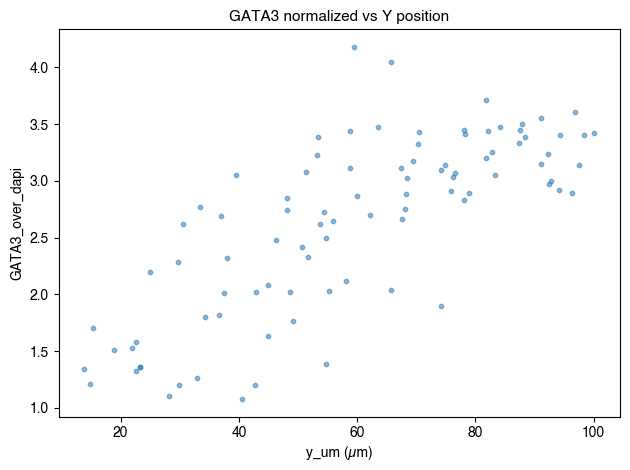

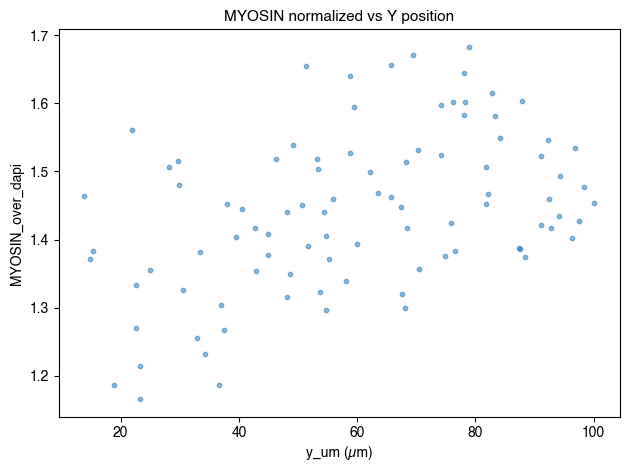

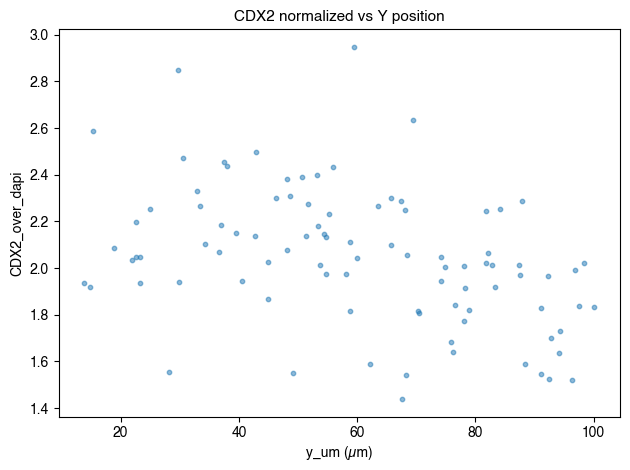

In [238]:
def scatter_y_vs_ratio(df, ycol, valcol, title):
    m = np.isfinite(df[ycol]) & np.isfinite(df[valcol])
    x = df.loc[m, ycol].to_numpy()
    y = df.loc[m, valcol].to_numpy()

    plt.figure()
    plt.scatter(x, y, s=10, alpha=0.5)
    plt.xlabel(f"{ycol} (µm)")
    plt.ylabel(valcol)
    plt.title(title)
    plt.tight_layout()
    plt.show()

ycol = "y_um"  # or "y_um_from_bottom"

scatter_y_vs_ratio(df, ycol, "GATA3_over_dapi",  "GATA3 normalized vs Y position")
scatter_y_vs_ratio(df, ycol, "MYOSIN_over_dapi", "MYOSIN normalized vs Y position")
scatter_y_vs_ratio(df, ycol, "CDX2_over_dapi",   "CDX2 normalized vs Y position")

In [239]:
#save em
def save_scatter_plot(df, ycol, valcol, title, filename, dpi=300):
    m = np.isfinite(df[ycol]) & np.isfinite(df[valcol])
    x = df.loc[m, ycol].to_numpy()
    y = df.loc[m, valcol].to_numpy()

    fig, ax = plt.subplots(figsize=(5, 4))
    ax.scatter(x, y, s=10, alpha=0.5)

    ax.set_xlabel(f"{ycol} (µm)")
    ax.set_ylabel(valcol)
    ax.set_title(title)

    fig.tight_layout()
    out_path = os.path.join(out_dir, f"{identifier}_{filename}.png")
    fig.savefig(out_path, dpi=dpi)
    plt.close(fig)

    print(f"Saved: {out_path}")
ycol = "y_um"  # or y_um_from_bottom

# Scatter only
save_scatter_plot(df, ycol, "GATA3_over_dapi",
                  "GATA3 normalized vs Y",
                  "GATA3_vs_Y_scatter")

save_scatter_plot(df, ycol, "MYOSIN_over_dapi",
                  "MYOSIN normalized vs Y",
                  "MYOSIN_vs_Y_scatter")

save_scatter_plot(df, ycol, "CDX2_over_dapi",
                  "CDX2 normalized vs Y",
                  "CDX2_vs_Y_scatter")

Saved: /Users/elyssephillips/Desktop/20260129_fgf_cdx2_ppmlc_gata3/tifs/analyzed/c_001_GATA3_vs_Y_scatter.png
Saved: /Users/elyssephillips/Desktop/20260129_fgf_cdx2_ppmlc_gata3/tifs/analyzed/c_001_MYOSIN_vs_Y_scatter.png
Saved: /Users/elyssephillips/Desktop/20260129_fgf_cdx2_ppmlc_gata3/tifs/analyzed/c_001_CDX2_vs_Y_scatter.png


In [240]:
#normalize y
os.makedirs(out_dir, exist_ok=True)

# Choose which y you want to use
ycol_um = "y_um"  # or "y_um_from_bottom"

# Normalize y to [0, 1] using observed nuclei range
ymin = float(df[ycol_um].min())
ymax = float(df[ycol_um].max())
df["y_norm"] = (df[ycol_um] - ymin) / (ymax - ymin + 1e-12)

print("y range (µm):", ymin, "to", ymax)
df[["label_id", ycol_um, "y_norm"]].head()

y range (µm): 13.796830909310666 to 100.13578595129633


,label_id,y_um,y_norm
0,1,37.938722,0.279618
1,2,28.137873,0.166102
2,3,98.414444,0.980063
3,4,92.221025,0.908329
4,5,92.700620,0.913884


/var/folders/j5/y4_p0dy97qjgh64xf1q725cw0000gn/T/ipykernel_71713/360976437.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  centers = dfb.groupby("bin")["x"].median().to_numpy()
/var/folders/j5/y4_p0dy97qjgh64xf1q725cw0000gn/T/ipykernel_71713/360976437.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = dfb.groupby("bin")["y"].size().to_numpy()
/var/folders/j5/y4_p0dy97qjgh64xf1q725cw0000gn/T/ipykernel_71713/360976437.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or obser

<Figure size 500x400 with 0 Axes>

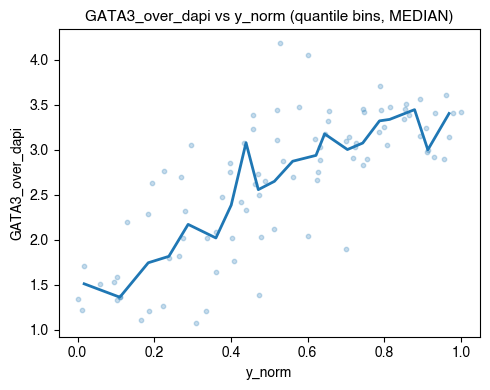

/var/folders/j5/y4_p0dy97qjgh64xf1q725cw0000gn/T/ipykernel_71713/360976437.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  centers = dfb.groupby("bin")["x"].median().to_numpy()
/var/folders/j5/y4_p0dy97qjgh64xf1q725cw0000gn/T/ipykernel_71713/360976437.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = dfb.groupby("bin")["y"].size().to_numpy()
/var/folders/j5/y4_p0dy97qjgh64xf1q725cw0000gn/T/ipykernel_71713/360976437.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or obser

<Figure size 500x400 with 0 Axes>

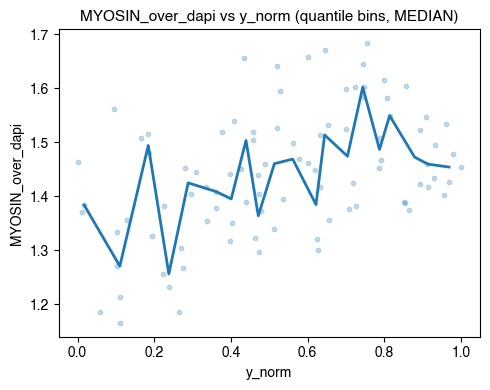

/var/folders/j5/y4_p0dy97qjgh64xf1q725cw0000gn/T/ipykernel_71713/360976437.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  centers = dfb.groupby("bin")["x"].median().to_numpy()
/var/folders/j5/y4_p0dy97qjgh64xf1q725cw0000gn/T/ipykernel_71713/360976437.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = dfb.groupby("bin")["y"].size().to_numpy()
/var/folders/j5/y4_p0dy97qjgh64xf1q725cw0000gn/T/ipykernel_71713/360976437.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or obser

<Figure size 500x400 with 0 Axes>

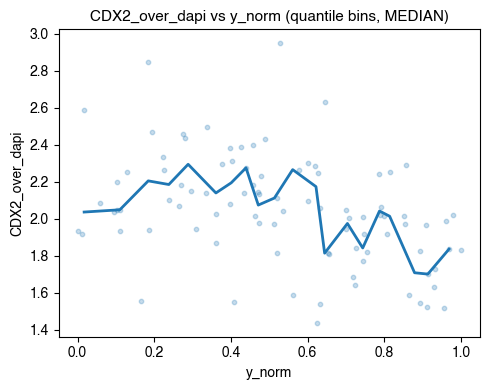

/var/folders/j5/y4_p0dy97qjgh64xf1q725cw0000gn/T/ipykernel_71713/360976437.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  centers = dfb.groupby("bin")["x"].median().to_numpy()
/var/folders/j5/y4_p0dy97qjgh64xf1q725cw0000gn/T/ipykernel_71713/360976437.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = dfb.groupby("bin")["y"].size().to_numpy()
/var/folders/j5/y4_p0dy97qjgh64xf1q725cw0000gn/T/ipykernel_71713/360976437.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or obser

<Figure size 500x400 with 0 Axes>

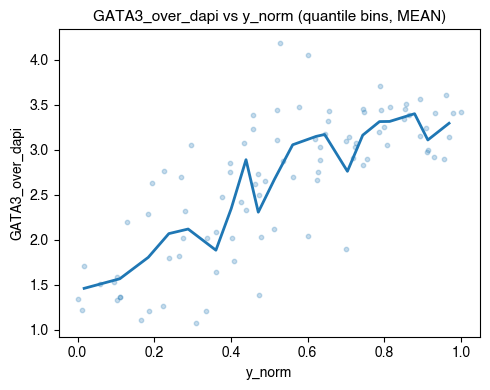

/var/folders/j5/y4_p0dy97qjgh64xf1q725cw0000gn/T/ipykernel_71713/360976437.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  centers = dfb.groupby("bin")["x"].median().to_numpy()
/var/folders/j5/y4_p0dy97qjgh64xf1q725cw0000gn/T/ipykernel_71713/360976437.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = dfb.groupby("bin")["y"].size().to_numpy()
/var/folders/j5/y4_p0dy97qjgh64xf1q725cw0000gn/T/ipykernel_71713/360976437.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or obser

<Figure size 500x400 with 0 Axes>

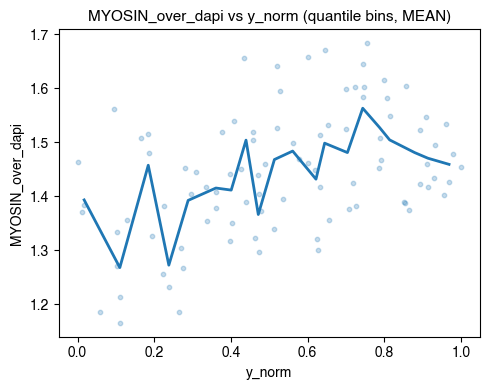

/var/folders/j5/y4_p0dy97qjgh64xf1q725cw0000gn/T/ipykernel_71713/360976437.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  centers = dfb.groupby("bin")["x"].median().to_numpy()
/var/folders/j5/y4_p0dy97qjgh64xf1q725cw0000gn/T/ipykernel_71713/360976437.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = dfb.groupby("bin")["y"].size().to_numpy()
/var/folders/j5/y4_p0dy97qjgh64xf1q725cw0000gn/T/ipykernel_71713/360976437.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or obser

<Figure size 500x400 with 0 Axes>

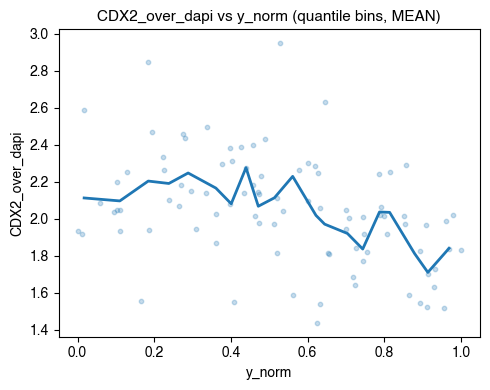

In [241]:
def quantile_binned_trend(x, y, nbins=15, stat="median"):
    """
    Equal-count bins in x (quantile bins).
    Returns:
      centers: median x in each bin
      values: mean/median y in each bin
      counts: number of points in each bin
    """
    dfb = pd.DataFrame({"x": x, "y": y}).replace([np.inf, -np.inf], np.nan).dropna()
    if len(dfb) < 3:
        return np.array([]), np.array([]), np.array([])

    # qcut makes bins with (roughly) equal number of nuclei
    dfb["bin"] = pd.qcut(dfb["x"], q=nbins, duplicates="drop")

    centers = dfb.groupby("bin")["x"].median().to_numpy()
    counts = dfb.groupby("bin")["y"].size().to_numpy()

    if stat == "mean":
        values = dfb.groupby("bin")["y"].mean().to_numpy()
    elif stat == "median":
        values = dfb.groupby("bin")["y"].median().to_numpy()
    else:
        raise ValueError("stat must be 'mean' or 'median'")

    return centers, values, counts


def plot_scatter_with_quantile_trend(df, xcol, ycol, nbins=20, stat="median", title=None, ax=None):
    m = np.isfinite(df[xcol]) & np.isfinite(df[ycol])
    x = df.loc[m, xcol].to_numpy()
    y = df.loc[m, ycol].to_numpy()

    if ax is None:
        fig, ax = plt.subplots(figsize=(5,4))

    ax.scatter(x, y, s=10, alpha=0.25)

    centers, values, counts = quantile_binned_trend(x, y, nbins=nbins, stat=stat)
    if len(centers) > 0:
        ax.plot(centers, values, linewidth=2)

    ax.set_xlabel(xcol)
    ax.set_ylabel(ycol)
    if title:
        ax.set_title(title)

    return ax

xcol = "y_norm"  # distance/position axis (0–1)
channels = ["GATA3_over_dapi", "MYOSIN_over_dapi", "CDX2_over_dapi"]

# Median versions
for ch in channels:
    plt.figure(figsize=(5,4))
    plot_scatter_with_quantile_trend(
        df, xcol, ch, nbins=20, stat="median",
        title=f"{ch} vs {xcol} (quantile bins, MEDIAN)"
    )
    plt.tight_layout()
    plt.show()

# Mean versions
for ch in channels:
    plt.figure(figsize=(5,4))
    plot_scatter_with_quantile_trend(
        df, xcol, ch, nbins=20, stat="mean",
        title=f"{ch} vs {xcol} (quantile bins, MEAN)"
    )
    plt.tight_layout()
    plt.show()


In [242]:
def save_3panel_quantile_binned(df, xcol, out_path, nbins=15, stat="median", dpi=300):
    chans = [
        ("GATA3_over_dapi",  "GATA3 / DAPI"),
        ("MYOSIN_over_dapi", "MYOSIN / DAPI"),
        ("CDX2_over_dapi",   "CDX2 / DAPI"),
    ]
    fig, axes = plt.subplots(1, 3, figsize=(12, 3.8), sharex=True, dpi=dpi, constrained_layout=True)

    for ax, (col, label) in zip(axes, chans):
        m = np.isfinite(df[xcol]) & np.isfinite(df[col])
        x = df.loc[m, xcol].to_numpy()
        y = df.loc[m, col].to_numpy()

        ax.scatter(x, y, s=10, alpha=0.20)
        centers, values, counts = quantile_binned_trend(x, y, nbins=nbins, stat=stat)
        if len(centers) > 0:
            ax.plot(centers, values, linewidth=2)

        ax.set_title(label)
        ax.set_xlabel(xcol)
        ax.grid(True, alpha=0.2)

    axes[0].set_ylabel("Normalized intensity (ratio)")
    fig.suptitle(f"{identifier} — {stat.upper()} trend (quantile bins, nbins={nbins})", fontsize=12)

    os.makedirs(os.path.dirname(out_path), exist_ok=True)
    fig.savefig(out_path, dpi=dpi)
    plt.close(fig)
    print("Saved:", out_path)

out_mean   = os.path.join(out_dir, f"{identifier}_3panel_quantile_MEAN.png")
out_median = os.path.join(out_dir, f"{identifier}_3panel_quantile_MEDIAN.png")

save_3panel_quantile_binned(df, xcol="y_norm", out_path=out_mean,   nbins=20, stat="mean")
save_3panel_quantile_binned(df, xcol="y_norm", out_path=out_median, nbins=20, stat="median")

/var/folders/j5/y4_p0dy97qjgh64xf1q725cw0000gn/T/ipykernel_71713/360976437.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  centers = dfb.groupby("bin")["x"].median().to_numpy()
/var/folders/j5/y4_p0dy97qjgh64xf1q725cw0000gn/T/ipykernel_71713/360976437.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = dfb.groupby("bin")["y"].size().to_numpy()
/var/folders/j5/y4_p0dy97qjgh64xf1q725cw0000gn/T/ipykernel_71713/360976437.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or obser

Saved: /Users/elyssephillips/Desktop/20260129_fgf_cdx2_ppmlc_gata3/tifs/analyzed/c_001_3panel_quantile_MEAN.png


/var/folders/j5/y4_p0dy97qjgh64xf1q725cw0000gn/T/ipykernel_71713/360976437.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  centers = dfb.groupby("bin")["x"].median().to_numpy()
/var/folders/j5/y4_p0dy97qjgh64xf1q725cw0000gn/T/ipykernel_71713/360976437.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = dfb.groupby("bin")["y"].size().to_numpy()
/var/folders/j5/y4_p0dy97qjgh64xf1q725cw0000gn/T/ipykernel_71713/360976437.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or obser

Saved: /Users/elyssephillips/Desktop/20260129_fgf_cdx2_ppmlc_gata3/tifs/analyzed/c_001_3panel_quantile_MEDIAN.png


In [243]:
from scipy.stats import spearmanr

def compute_gradient_stats(df, xcol, ycol):
    m = np.isfinite(df[xcol]) & np.isfinite(df[ycol])
    x = df.loc[m, xcol].to_numpy()
    y = df.loc[m, ycol].to_numpy()

    if len(x) < 3:
        return dict(slope=np.nan, intercept=np.nan, r2=np.nan,
                    spearman_r=np.nan, spearman_p=np.nan,
                    n=len(x))

    # Linear fit
    slope, intercept = np.polyfit(x, y, 1)
    yhat = slope * x + intercept
    ss_res = np.sum((y - yhat) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan

    # Spearman correlation (monotonic trend)
    spearman_r, spearman_p = spearmanr(x, y)

    return dict(
        slope=slope,
        intercept=intercept,
        r2=r2,
        spearman_r=spearman_r,
        spearman_p=spearman_p,
        n=len(x),
    )

channels = [
    "GATA3_over_dapi",
    "MYOSIN_over_dapi",
    "CDX2_over_dapi",
]

results = []

for ch in channels:
    stats = compute_gradient_stats(df, "y_norm", ch)
    stats["identifier"] = identifier
    stats["channel"] = ch.replace("_over_DAPI", "")
    results.append(stats)

df_stats = pd.DataFrame(results)
df_stats

,slope,intercept,r2,spearman_r,spearman_p,n,identifier,channel
0,2.148257,1.493815,0.582376,0.771450,2.301938e-19,92,c_001,GATA3_over_dapi
1,0.186139,1.342813,0.193910,0.427277,2.158826e-05,92,c_001,MYOSIN_over_dapi
2,-0.431371,2.278462,0.163420,-0.445802,8.451851e-06,92,c_001,CDX2_over_dapi


In [244]:
os.makedirs(out_dir, exist_ok=True)

out_csv = os.path.join(out_dir, f"{identifier}_gradient_stats.csv")
df_stats.to_csv(out_csv, index=False)

print("Saved:", out_csv)

Saved: /Users/elyssephillips/Desktop/20260129_fgf_cdx2_ppmlc_gata3/tifs/analyzed/c_001_gradient_stats.csv
